# 🏏 IPL Match Analysis 

**Dataset**:`SRH_VS_RR_MATCH_NO.2.csv`    
**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Plotly

---

## Objective

The objective of this project is to uncover actionable insights from a single IPL match dataset by applying exploratory data analysis (EDA) and impactful visualizations. The focus areas include:

- Evaluating individual and team performances in batting and bowling.
- Analyzing key match phases and identifying momentum shifts.
- Highlighting high-impact players based on data-driven metrics.
- Simulating the thought process of a professional cricket analyst.

The ultimate goal is to provide a detailed, data-driven narrative that helps coaches, commentators, and decision-makers better understand match dynamics beyond surface-level statistics.

## Importing Required Libraries

This section imports the necessary libraries for data manipulation, visualization, and analysis.


In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import plotly.express as px
from matplotlib.lines import Line2D
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 500)

# Other useful libraries 
import warnings
warnings.filterwarnings('ignore')

## Dataset Description

**Match:** Sunrisers Hyderabad vs Rajasthan Royals  
**Match Number:** 2  

This dataset contains ball-by-ball data from the IPL match between Sunrisers Hyderabad and Rajasthan Royals. 
Key columns for analysis include:

- **Match & Context:** `Date`, `Innings`, `Over Number`, `Over Ball`, `Day`, `Session`
- **Teams & Players:** `Batting Team`, `Bowling Team`, `Striker`, `Non-Striker`, `Bowler`
- **Runs & Extras:** `Runs`, `Wides`, `No Balls`, `Leg Byes`, `Byes`, `Team Runs`
- **Batting Performance:** `Batter Runs`, `Batter Balls`, `Batter Sixes`, `Batter Fours`, `Batter Total Runs`
- **Dismissals:** `Dismissal Type`, `Dismissal Fielder`
- **Bowling Details:** `Bowling Type`, `Bowling Hand`, `Delivery Type`
- **Match Progress:** `Remaining Balls`, `Remaining Overs`, `Run Rate`, `Lead By`, `Trail By`, `Fall Of Wickets`



In [2]:
# Loading the SRH vs RR Match No. 2 dataset into a pandas DataFrame
df = pd.read_csv("SRH_VS_RR_MATCH_NO.2.csv")
df.head()

,Date,Batting Team,Bowling Team,Striker,Non-Striker,Bowler,Innings,Unique,Over Number,Over Ball,Runs,Wides,Team Runs,Remaining Overs,Lead By,Trail By,Fall Of Wickets,Day,Session,Leg Byes,No Balls,Balls,Byes,Remaining Balls,Remaining Runs,Run Rate,Batter Sixes,Batter Runs,Batter Fours,Batter Balls,Batter Total Runs,Dismissal Type,Dismissal Fielder,On Field Minutes,Shot Angle,Shot Magnitude,Wagon Position,Pitching Length,Pitching Line,Shot Connection,False Shot,Feet Movement,Shot Type,Delivery Type,Bowling Side,Bowling Type,Bowling Hand,Catch Difficulty,Bounce_Angle,Pitch_x,Pitch_y,Friction,Restitution,Deviation,Reaction Time,Release Speed,Swing,Swing Distance,Six Distance
0,2025-3-24 15:30:00,Sunrisers Hyderabad,Rajasthan Royals,Abhishek Sharma,Travis Head,Fazalhaq Farooqi,1,0.1,1,1,0,0,0,19.5,0,0,0,1,1,0,0,1,0,119,NaN,0.0,0,0,0,1,0,NaN,NaN,0,251,96,Mid On,Length Delivery,Off stump,MisTimed,1,Front Foot,Slog,Out Swing,Over,Fast,Left,0.0,7.404,5.869,0.149,0.159,0.613,0.271,0.492,82.348,2.972,0.317,-1.0
1,2025-3-24 15:30:00,Sunrisers Hyderabad,Rajasthan Royals,Abhishek Sharma,Travis Head,Fazalhaq Farooqi,1,0.2,1,2,0,0,0,19.4,0,0,0,1,1,0,0,2,0,118,NaN,0.0,0,0,0,2,0,NaN,NaN,0,43,92,Short Third Man,Yorker,Off stump,Thick Edge,1,Front Foot,Drive,Out Swing,Over,Fast,Left,0.0,7.975,1.534,0.161,0.272,0.724,-0.225,0.502,80.472,4.144,0.575,-1.0
2,2025-3-24 15:30:00,Sunrisers Hyderabad,Rajasthan Royals,Abhishek Sharma,Travis Head,Fazalhaq Farooqi,1,0.3,1,3,4,0,4,19.3,0,0,0,1,1,0,0,3,0,117,NaN,8.0,0,4,1,3,4,NaN,NaN,0,229,218,Long On,Full Toss,Off stump,Middled,0,Front Foot,Flick,InSwinger,Over,Fast,Left,0.0,7.066,-0.079,0.005,0.168,0.650,0.000,0.484,81.437,-3.651,-0.440,-1.0
3,2025-3-24 15:30:00,Sunrisers Hyderabad,Rajasthan Royals,Abhishek Sharma,Travis Head,Fazalhaq Farooqi,1,0.4,1,4,4,0,8,19.2,0,0,0,1,1,0,0,4,0,116,NaN,12.0,0,4,2,4,8,NaN,NaN,0,346,194,Deep Cover,Length Delivery,Off stump,Middled,0,Down The Track,Drive,Out Swing,Over,Fast,Left,0.0,7.404,6.407,0.028,0.191,0.610,0.266,0.455,84.515,2.220,0.220,-1.0
4,2025-3-24 15:30:00,Sunrisers Hyderabad,Rajasthan Royals,Abhishek Sharma,Travis Head,Fazalhaq Farooqi,1,0.5,1,5,1,0,9,19.1,0,0,0,1,1,0,0,5,0,115,NaN,10.8,0,1,2,5,9,NaN,NaN,0,161,153,Deep Backward Square Leg,Half Volley,Leg stump,Middled,0,Front Foot,Flick,InSwinger,Over,Fast,Left,0.0,7.194,2.091,-0.099,0.097,0.666,0.467,0.489,82.162,-3.265,-0.437,-1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 59 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               262 non-null    object 
 1   Batting Team       262 non-null    object 
 2   Bowling Team       262 non-null    object 
 3   Striker            262 non-null    object 
 4   Non-Striker        262 non-null    object 
 5   Bowler             262 non-null    object 
 6   Innings            262 non-null    int64  
 7   Unique             262 non-null    float64
 8   Over Number        262 non-null    int64  
 9   Over Ball          262 non-null    int64  
 10  Runs               262 non-null    int64  
 11  Wides              262 non-null    int64  
 12  Team Runs          262 non-null    int64  
 13  Remaining Overs    262 non-null    float64
 14  Lead By            262 non-null    int64  
 15  Trail By           262 non-null    int64  
 16  Fall Of Wickets    262 non

## Data Preprocessing

### Handling Missing Values

In [4]:
df['Remaining Runs'].fillna(0, inplace=True)
df['Dismissal Type'].fillna('No Wicket', inplace=True)
df['Dismissal Fielder'].fillna('No Wicket', inplace=True)
# Filled missing values in the 'Remaining Runs' column with 0
# Replaced NaNs in 'Dismissal Type' and 'Dismissal Fielder' with 'No Wicket' 
# to indicate that no dismissal occurred for those entries.

### Dropping Irrelevant Columns Based on Cardinality

In [5]:
# Identifying Low Cardinality Features
# Loop through all columns and print the number of unique values for columns having fewer than 5 unique values.
for i in df.columns.to_list():
    if df[i].nunique()<5:
        print(f"No of Unique Values in '{i}' column is {df[i].nunique()} and they are{df[i].unique()}")

No of Unique Values in 'Date' column is 1 and they are['2025-3-24 15:30:00']
No of Unique Values in 'Batting Team' column is 2 and they are['Sunrisers Hyderabad' 'Rajasthan Royals']
No of Unique Values in 'Bowling Team' column is 2 and they are['Rajasthan Royals' 'Sunrisers Hyderabad']
No of Unique Values in 'Innings' column is 2 and they are[1 2]
No of Unique Values in 'Wides' column is 2 and they are[0 1]
No of Unique Values in 'Lead By' column is 1 and they are[0]
No of Unique Values in 'Trail By' column is 1 and they are[0]
No of Unique Values in 'Day' column is 1 and they are[1]
No of Unique Values in 'Session' column is 1 and they are[1]
No of Unique Values in 'Leg Byes' column is 2 and they are[0 1]
No of Unique Values in 'No Balls' column is 2 and they are[0 1]
No of Unique Values in 'Byes' column is 2 and they are[0 4]
No of Unique Values in 'Dismissal Type' column is 2 and they are['No Wicket' 'caught']
No of Unique Values in 'False Shot' column is 2 and they are[1 0]
No of U

In [6]:
# Dropping Irrelevant Columns
# The columns 'Date', 'Lead By', 'Trail By', 'Day', and 'Session' are removed
# As they do not contribute meaningful information for the analysis
df.drop(columns=['Date', 'Lead By', 'Trail By', 'Day', 'Session'], inplace=True)

## Feature Engineering
### Categorizing Bowlers Based on Release Speed

We classify bowlers into distinct speed categories by segmenting the 'Release Speed' continuous variable into five bins: Slow, Medium, Medium-Fast, Fast-Medium, and Very Fast.  
This helps in analyzing bowling performance and patterns based on speed groups rather than raw numeric values.  
The `pd.cut()` function is used to create these categorical labels corresponding to defined speed intervals.

In [7]:
bins = [47, 59, 74, 80, 88, 92]  
labels = ['Slow', 'Medium', 'Medium-Fast', 'Fast-Medium', 'Very Fast']

df['Bowl_Label'] = pd.cut(df['Release Speed'], bins=bins, labels=labels, right=False)

### Phase Classification Based on Over Number

Created a new feature `Phase` to categorize each over into match phases:
- **Powerplay** (Overs 1–6)
- **Middle** (Overs 7–15)
- **Death** (Overs 16-20)


In [8]:
def overs_classification(over):
    if over<=6:
        return 'Powerplay'
    elif over>=6 and over<=15:
        return 'Middle'
    else:
        return 'Death'
df['Phase']=df['Over Number'].apply(overs_classification)

In [9]:
df['Wicket']=df['Fall Of Wickets']>0

## Exploratory Data Analysis (EDA)

In [10]:
df.describe()

,Innings,Unique,Over Number,Over Ball,Runs,Wides,Team Runs,Remaining Overs,Fall Of Wickets,Leg Byes,No Balls,Balls,Byes,Remaining Balls,Remaining Runs,Run Rate,Batter Sixes,Batter Runs,Batter Fours,Batter Balls,Batter Total Runs,On Field Minutes,Shot Angle,Shot Magnitude,False Shot,Catch Difficulty,Bounce_Angle,Pitch_x,Pitch_y,Friction,Restitution,Deviation,Reaction Time,Release Speed,Swing,Swing Distance,Six Distance
count,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,1.492366,9.944656,10.599237,3.816794,2.015267,0.064885,129.935115,9.672901,0.160305,0.003817,0.019084,60.965649,0.030534,59.034351,82.637405,12.589618,1.751908,1.896947,3.591603,15.114504,31.667939,1.110687,202.580153,137.148855,0.461832,0.110687,9.705794,6.869847,0.000229,0.218118,0.609252,0.186370,0.586557,73.814931,0.036321,0.001252,6.721374
std,0.500899,5.794477,5.793020,1.948775,2.001856,0.246795,75.189566,5.794573,0.819464,0.061780,0.137082,34.776169,0.348811,34.776169,96.774267,2.138668,1.693886,2.053142,2.817094,11.370218,24.224850,6.756235,102.698305,58.450791,0.499495,0.478624,2.619379,3.895058,0.536370,0.089715,0.074495,1.549384,0.100154,11.076587,1.152533,0.125834,24.007874
min,1.000000,0.100000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,4.070000,-11.423000,-1.140000,-0.183000,0.253000,-6.246000,0.440000,49.834000,-4.550000,-0.505000,-1.000000
25%,1.000000,5.100000,6.000000,2.000000,1.000000,0.000000,71.250000,4.625000,0.000000,0.000000,0.000000,31.000000,0.000000,29.250000,0.000000,11.562500,0.000000,0.000000,1.000000,6.000000,10.250000,0.000000,90.000000,90.000000,0.000000,0.000000,7.761250,4.262500,-0.391500,0.167000,0.575000,-0.316000,0.505000,64.102250,-0.514500,-0.052500,-1.000000
50%,1.000000,10.200000,11.000000,4.000000,1.000000,0.000000,124.500000,9.400000,0.000000,0.000000,0.000000,62.000000,0.000000,58.000000,0.000000,12.535000,1.000000,1.000000,4.000000,12.500000,29.000000,0.000000,212.500000,150.000000,0.000000,0.000000,9.323000,6.572000,-0.019000,0.207500,0.620000,0.091000,0.569500,75.630000,0.055000,0.005000,-1.000000
75%,2.000000,14.975000,15.750000,5.000000,4.000000,0.000000,190.500000,14.500000,0.000000,0.000000,0.000000,90.750000,0.000000,89.000000,166.750000,13.970000,3.000000,4.000000,6.000000,23.000000,48.000000,0.000000,293.750000,191.000000,1.000000,0.000000,11.077000,9.366750,0.465750,0.274750,0.650000,1.027750,0.665000,83.695250,0.643750,0.060750,-1.000000
max,2.000000,19.600000,20.000000,8.000000,6.000000,1.000000,286.000000,19.500000,6.000000,1.000000,1.000000,120.000000,4.000000,119.000000,287.000000,16.120000,6.000000,6.000000,11.000000,47.000000,106.000000,69.000000,359.000000,228.000000,1.000000,3.000000,18.834000,14.976000,1.134000,0.475000,1.065000,5.403000,0.872000,91.815000,4.144000,0.575000,105.000000


### Univariate Analysis

In [11]:
team_palette = {
    'Sunrisers Hyderabad': '#EE7429',
    'Rajasthan Royals': 'deeppink'  
}

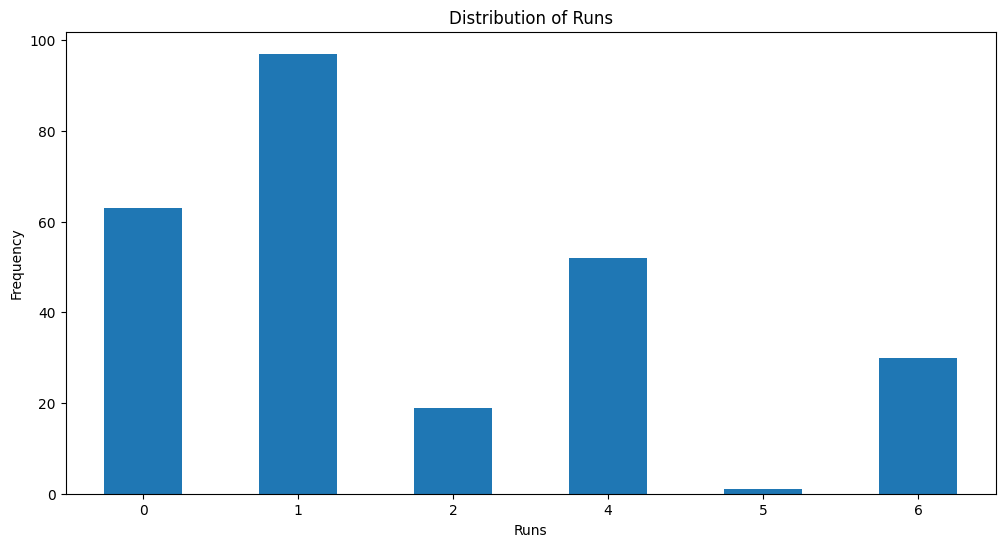

In [12]:
plt.figure(figsize=(12,6))
df.groupby('Runs')['Runs'].count().plot(kind='bar')
plt.title('Distribution of Runs')
plt.xlabel('Runs')
plt.xticks(rotation=0)
plt.ylabel('Frequency')
plt.show()

This histogram displays the distribution of runs scored on each ball during the match. Most deliveries result in 0 to 2 runs, with occasional spikes for boundaries and sixes, which is typical in a T20 game.

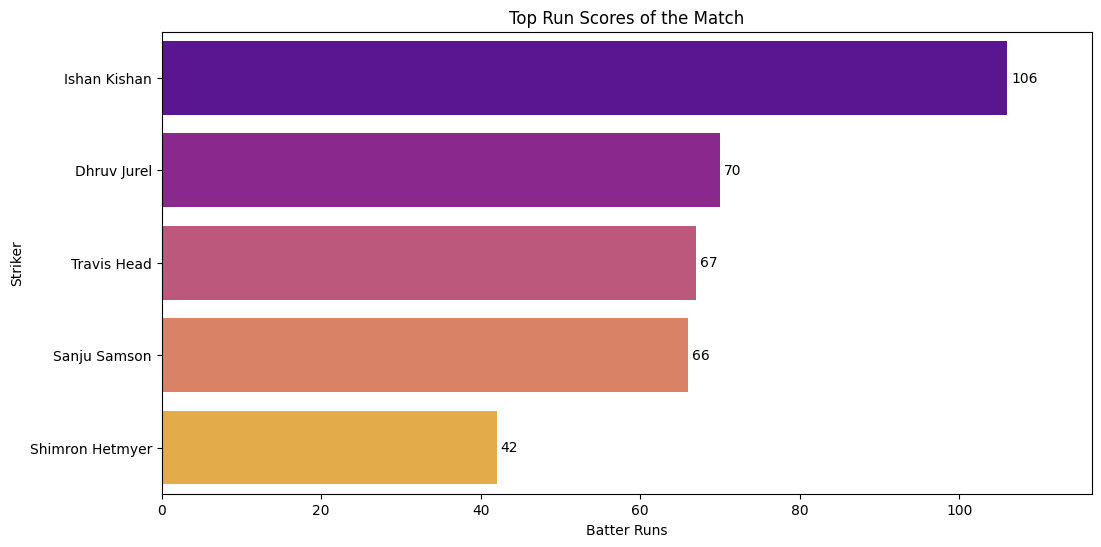

In [13]:
plt.figure(figsize=(12,6))
sixes_df = df.groupby('Striker')['Batter Runs'].sum().to_frame().sort_values(by='Batter Runs', ascending=False)

ax = sns.barplot(x='Batter Runs', y='Striker', data=sixes_df[:5], palette='plasma')
plt.title('Top Run Scores of the Match')

# Add text labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=10, color='black')

plt.margins(x=0.1)  
plt.show()


This bar plot visualizes the total number of sixes hit by each batter. It helps identify the most powerful hitters in the dataset and their contribution to the team's scoring through sixes. The players are sorted in descending order to highlight the top six-hitters.

### Bivariate Analysis

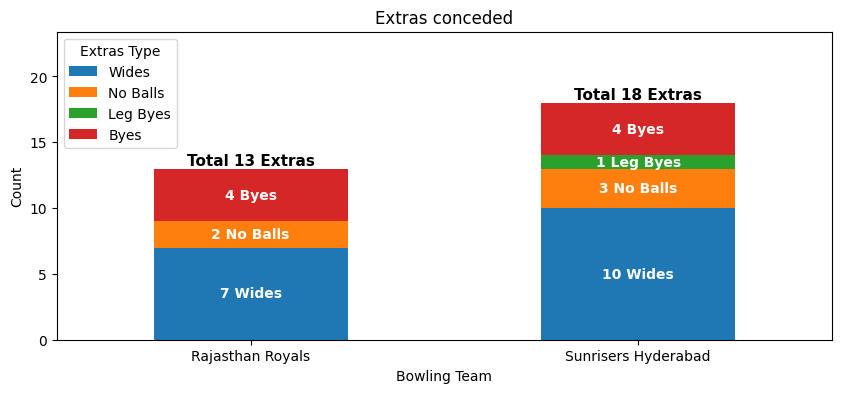

In [14]:
df_extras = df.groupby('Batting Team').agg(
                Wides=('Wides', 'sum'),
                NoBalls=('No Balls', 'sum'),
                Leg_Byes=('Leg Byes', 'sum'),
                Byes=('Byes', 'sum')
)
df_extras.rename({'NoBalls': 'No Balls', 'Leg_Byes': 'Leg Byes'}, axis=1, inplace=True)
df_extras = df_extras.apply(pd.to_numeric)
ax = df_extras.plot(kind='bar', stacked=True, figsize=(10,4))
plt.title('Extras conceded')
plt.ylabel('Count')
plt.xlabel('Bowling Team')
plt.xticks(rotation=0)
# Make y-axis ticks as integers
ax.yaxis.get_major_locator().set_params(integer=True)

# Add text labels inside each stack
for i, team in enumerate(df_extras.index):
    cumulative_height = 0
    for extra in df_extras.columns:
        height = df_extras.loc[team, extra]
        if height > 0:
            ax.text(i, cumulative_height + height / 2, f'{str(height)} {extra}', 
                    ha='center', va='center', color='white', fontsize=10, fontweight='bold')
            cumulative_height += height
df_extras['Total'] = df_extras.sum(axis=1)
for i, team in enumerate(df_extras['Total']):
    total_extras = df_extras['Total'][i]
    ax.text(i, total_extras , f'Total {int(total_extras)} Extras',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')
plt.margins(y=0.3)
plt.legend(title='Extras Type')
plt.show()

##### Insight :
Sunrisers Hyderabad conceded more extras overall (18) than Rajasthan Royals (13), mainly because of a higher number of wides and no balls.

In [15]:
# Grouping by Batting Team and Striker to calculate batter-wise stats
df_scorecard = df.groupby(['Batting Team', 'Striker']).agg(
    remaining_balls=('Remaining Balls', 'max'),  # Max remaining balls faced (used for batting order)
    Runs=('Batter Runs', 'sum'),                # Total runs scored by the batter
    Balls=('Batter Balls', 'max'),              # Total balls faced by the batter
    Fours=('Batter Fours', 'max'),              # Total number of 4s hit
    Sixes=('Batter Sixes', 'max')               # Total number of 6s hit
).reset_index().sort_values(
    ['Batting Team', 'remaining_balls'], 
    ascending=False                             # Sorting to determine batting order
)

# Dropping remaining_balls after assigning batting position
df_scorecard.drop(['remaining_balls'], axis=1, inplace=True)

# Creating Batting Position using cumcount (1 = opener, 2 = one-down, etc.)
df_scorecard['Batting Position'] = (df_scorecard.groupby('Batting Team', sort=False).cumcount() + 1)

# Calculating Strike Rate = (Runs / Balls) * 100
df_scorecard['Strike Rate'] = round(df_scorecard['Runs'] / df_scorecard['Balls'] * 100, 2)

# Setting Batting Team as index for cleaner display
df_scorecard.set_index('Batting Team', inplace=True)

# Function to classify Player Role based on Batting Position
def player_role(position):
    if position <= 3:
        return 'Top Order'
    elif position > 3 and position <= 6:
        return 'Middle Order'
    else:
        return 'Lower Middle Order'

# Applying role classification to each batter
df_scorecard['Player Role'] = df_scorecard['Batting Position'].apply(player_role)

# Displaying the final batter-wise scorecard
df_scorecard.to_csv('Batting.csv')
df_scorecard['Runs/Balls'] = df_scorecard.apply(lambda x: f"{x['Runs']} ({x['Balls']})", axis=1)
df_bat = df_scorecard.sort_values('Runs', ascending=False).groupby('Batting Team')[['Striker', 'Runs', 'Runs/Balls']].head(3).sort_values('Batting Team', ascending=False)
df_scorecard

,Striker,Runs,Balls,Fours,Sixes,Batting Position,Strike Rate,Player Role,Runs/Balls
Batting Team,,,,,,,,,
Sunrisers Hyderabad,Abhishek Sharma,24,11,5,0,1,218.18,Top Order,24 (11)
Sunrisers Hyderabad,Travis Head,67,31,9,3,2,216.13,Top Order,67 (31)
Sunrisers Hyderabad,Ishan Kishan,106,47,11,6,3,225.53,Top Order,106 (47)
Sunrisers Hyderabad,Nitish Kumar Reddy,30,15,4,1,4,200.00,Middle Order,30 (15)
Sunrisers Hyderabad,Heinrich Klaasen,34,14,5,1,5,242.86,Middle Order,34 (14)
Sunrisers Hyderabad,Aniket Verma,7,3,0,1,6,233.33,Middle Order,7 (3)
Sunrisers Hyderabad,Abhinav Manohar,0,1,0,0,7,0.00,Lower Middle Order,0 (1)
Sunrisers Hyderabad,Pat Cummins,0,1,0,0,8,0.00,Lower Middle Order,0 (1)
Rajasthan Royals,Yashasvi Jaiswal,1,5,0,0,1,20.00,Top Order,1 (5)


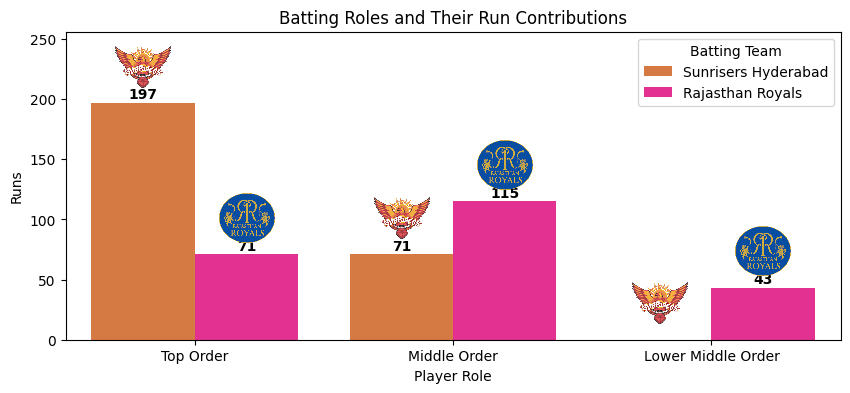

In [16]:
player_role_runs = df_scorecard.groupby(
                ['Batting Team', 'Player Role']
)['Runs'].sum().reset_index().sort_values(
['Batting Team', 'Player Role'], ascending=False)

# Create grouped bar plot
plt.figure(figsize=(10,4))
ax = sns.barplot(x='Player Role', y='Runs', hue='Batting Team', data=player_role_runs, ci=None, palette=team_palette)

# Add text labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,  # x position: center of the bar
            height + 1,                     # y position: a bit above the bar
            int(height),                   # label text
            ha='center',                   # horizontal alignment
            va='bottom',                   # vertical alignment
            fontsize=10,
            fontweight='bold'
        )
logos = {'Rajasthan Royals': 'RR.png', 'Sunrisers Hyderabad': 'SRH.png'}

for bar, team in zip(ax.patches, player_role_runs['Batting Team']):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height() + 30
    img = mpimg.imread(logos[team])
    imagebox = OffsetImage(img, zoom=0.1)  # Adjust zoom
    ab = AnnotationBbox(imagebox, (x, y), frameon=False)
    ax.add_artist(ab)
    
plt.margins(y=0.3)
plt.title('Batting Roles and Their Run Contributions')
plt.show()

#### Insight
SRH’s top order dominated because they preserved wickets, while RR’s early top-order collapse forced excessive dependence on the middle order, which became a major reason for their defeat.

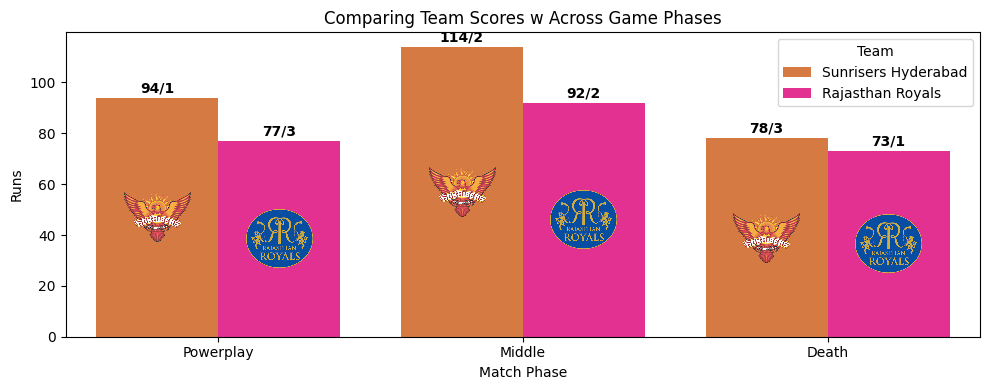

In [17]:
team_perf_phase = df.groupby(['Batting Team', 'Bowling Team', 'Phase']).agg(Runs=('Runs', 'sum'), Fall_of_Wickets=('Wicket', 'sum')).sort_values(['Batting Team', 'Phase'], ascending=False).reset_index()
team_perf_phase['Score_Label'] = team_perf_phase['Runs'].astype(str) + '/' + team_perf_phase['Fall_of_Wickets'].astype(str)
team_perf_phase.to_csv('team_perf_phase.csv')
# Plot
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=team_perf_phase, x='Phase', y='Runs', hue='Batting Team', palette=team_palette)

# Add score labels (Runs/Wickets)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,  # x position: center of the bar
            height + 1,                     # y position: a bit above the bar
            f'{team_perf_phase[team_perf_phase['Runs']==int(height)]['Score_Label'].values[0]}',                   
            ha='center',                   # horizontal alignment
            va='bottom',                   # vertical alignment
            fontsize=10,
            fontweight='bold'
        )
logos = {'Rajasthan Royals': 'RR.png', 'Sunrisers Hyderabad': 'SRH.png'}

for bar, team in zip(ax.patches, team_perf_phase['Batting Team']):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height() / 2
    img = mpimg.imread(logos[team])
    imagebox = OffsetImage(img, zoom=0.12) 
    ab = AnnotationBbox(imagebox, (x, y), frameon=False)
    ax.add_artist(ab)
    

plt.title('Comparing Team Scores w Across Game Phases')
plt.ylabel('Runs')
plt.xlabel('Match Phase')
plt.legend(title='Team')
plt.tight_layout()
plt.savefig('phasewisescore')
plt.show()

#### Insight 
SRH outperformed RR in all three phases—powerplay, middle overs, and death overs—while also managing wickets better, which ultimately created the difference in the match.

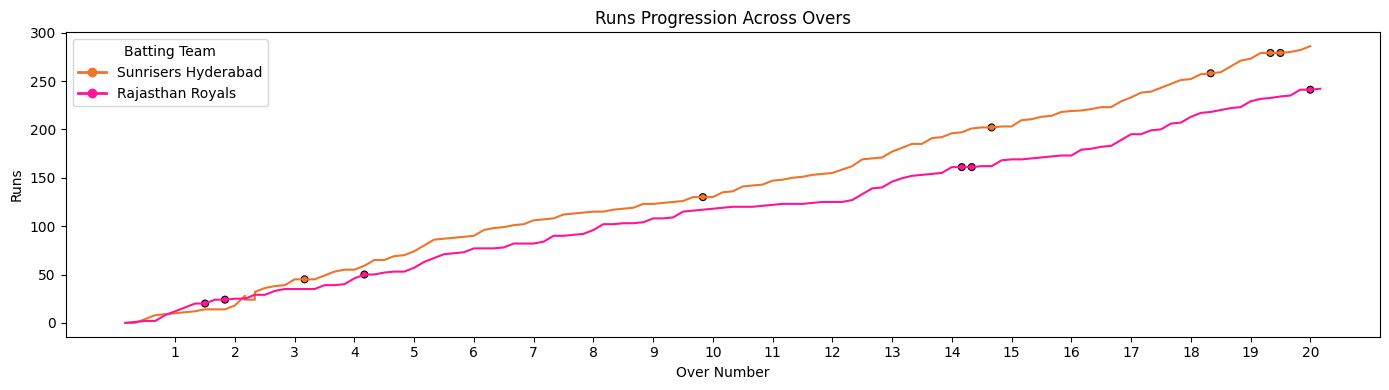

In [18]:
fig, ax = plt.subplots(figsize=(14,4))
df['Over%']=df['Over Number']+(df['Over Ball']/6) - 1
sns.lineplot(data=df, x='Over%', y='Team Runs', hue='Batting Team', palette=team_palette, estimator='mean', ci=None, ax=ax)
df2=df[df['Fall Of Wickets']>0]
sns.scatterplot(
    data=df2,
    x='Over%',
    y='Team Runs',
    hue='Batting Team',
    style='Batting Team',
    palette=team_palette,
    markers='.',
    s=100,
    edgecolor='black',
    ax=ax
)
plt.title('Runs Progression Across Overs')
plt.xlabel('Over Number')
plt.ylabel('Runs')
plt.xticks(ticks=range(df['Over Number'].min(), df['Over Number'].max()+1)) 
plt.tight_layout()
legend_elements = [
    Line2D([0], [0], color=color, lw=2, label=team, marker='o', linestyle='-')
    for team, color in team_palette.items()
]

# Add legend with handles and labels
ax.legend(handles=legend_elements, title='Batting Team')
plt.savefig('Runs.png')
plt.show()

## Bowling Analysis

In [19]:
df['net_runs']=df['Runs']-(df['Byes']+df['Leg Byes'])
bowler = df.groupby(['Bowling Team', 'Bowler', 'Bowling Hand', 'Bowling Type']).agg(Runs=('net_runs', 'sum'), Balls=('Over Number', 'count'), Wickets=('Wicket', 'sum'))
bowler['Overs'] = (bowler['Balls']//6).astype('float')
bowler['Eco'] = round(bowler['Runs']/bowler['Overs'],2)
bowler['Average'] = np.where(bowler['Wickets'] > 0,
                                     round(bowler['Runs'] / bowler['Wickets'], 2),
                                     'N/A')
bowler['Strike_Rate'] = np.where(bowler['Wickets'] > 0,
                                     round((bowler['Overs']*6) / bowler['Wickets'], 2),
                                     'N/A')
bowler.drop(columns=['Balls'], inplace=True)
bowler.reset_index('Bowler')

Bowler  Runs  \
Bowling Team        Bowling Hand Bowling Type                             
Rajasthan Royals    Left         Fast            Fazalhaq Farooqi    49   
                    Right        Fast                Jofra Archer    76   
                                 OffSpin       Maheesh Theekshana    52   
                                 OffSpin              Nitish Rana     9   
                                 Medium            Sandeep Sharma    51   
                                 Medium          Tushar Deshpande    44   
Sunrisers Hyderabad Left         Orthodox         Abhishek Sharma    17   
                    Right        LegSpin               Adam Zampa    48   
                                 Fast               Harshal Patel    34   
                                 Fast              Mohammed Shami    33   
                                 Fast                 Pat Cummins    60   
                                 Fast             Simarjeet Singh    46   

                                               Wickets  Overs    Eco Average  \
Bowling Team        Bowling Hand Bowling Type                                  
Rajasthan Royals    Left         Fast                0    3.0  16.33     N/A   
                    Right        Fast                0    4.0  19.00     N/A   
                                 OffSpin             2    4.0  13.00    26.0   
                                 OffSpin             0    1.0   9.00     N/A   
                                 Medium              1    4.0  12.75    51.0   
                                 Medium              3    4.0  11.00   14.67   
Sunrisers Hyderabad Left         Orthodox            0    2.0   8.50     N/A   
                    Right        LegSpin             1    4.0  12.00    48.0   
                                 Fast                2    4.0   8.50    17.0   
                                 Fast                1    3.0  11.00    33.0   
                                 Fast                0    4.0  15.00     N/A   
                                 Fast                2    3.0  15.33    23.0   

                                              Strike_Rate  
Bowling Team        Bowling Hand Bowling Type              
Rajasthan Royals    Left         Fast                 N/A  
                    Right        Fast                 N/A  
                                 OffSpin             12.0  
                                 OffSpin              N/A  
                                 Medium              24.0  
                                 Medium               8.0  
Sunrisers Hyderabad Left         Orthodox             N/A  
                    Right        LegSpin             24.0  
                                 Fast                12.0  
                                 Fast                18.0  
                                 Fast                 N/A  
                                 Fast                 9.0

In [20]:
bowler['Runs-wickets'] = bowler.apply(lambda x: f"{x['Runs']}-{x['Wickets']}", axis=1)
df_bowler = bowler.sort_values(['Wickets', 'Runs'], ascending=False).reset_index(['Bowler', 'Bowling Hand', 'Bowling Type']).groupby('Bowling Team')[['Bowler', 'Runs', 'Runs-wickets']].head(3).sort_values('Bowling Team')
df_bowler

,Bowler,Runs,Runs-wickets
Bowling Team,,,
Rajasthan Royals,Tushar Deshpande,44,44-3
Rajasthan Royals,Maheesh Theekshana,52,52-2
Rajasthan Royals,Sandeep Sharma,51,51-1
Sunrisers Hyderabad,Simarjeet Singh,46,46-2
Sunrisers Hyderabad,Harshal Patel,34,34-2
Sunrisers Hyderabad,Adam Zampa,48,48-1


In [21]:
bowling_comparison = bowler.groupby(['Bowling Team', 'Bowling Hand', 'Bowling Type']).agg(Runs=('Runs', 'sum'), Overs=('Overs', 'sum'), Wickets=('Wickets', 'sum'))
bowling_comparison['Average'] = np.where(bowling_comparison['Wickets'] > 0,
                                     round(bowling_comparison['Runs'] / bowling_comparison['Wickets'], 2),
                                     'N/A')
bowling_comparison['Strike_Rate'] = np.where(bowling_comparison['Wickets'] > 0,
                                     round((bowling_comparison['Overs']*6) / bowling_comparison['Wickets'], 2),
                                     'N/A')
bowling_comparison['Eco']=round(bowling_comparison['Runs']/bowling_comparison['Overs'], 2)
bowling_comparison

Runs  Overs  Wickets Average  \
Bowling Team        Bowling Hand Bowling Type                                 
Rajasthan Royals    Left         Fast            49    3.0        0     N/A   
                    Right        Fast            76    4.0        0     N/A   
                                 Medium          95    8.0        4   23.75   
                                 OffSpin         61    5.0        2    30.5   
Sunrisers Hyderabad Left         Orthodox        17    2.0        0     N/A   
                    Right        Fast           173   14.0        5    34.6   
                                 LegSpin         48    4.0        1    48.0   

                                              Strike_Rate    Eco  
Bowling Team        Bowling Hand Bowling Type                     
Rajasthan Royals    Left         Fast                 N/A  16.33  
                    Right        Fast                 N/A  19.00  
                                 Medium              12.0  11.88  
                                 OffSpin             15.0  12.20  
Sunrisers Hyderabad Left         Orthodox             N/A   8.50  
                    Right        Fast                16.8  12.36  
                                 LegSpin             24.0  12.00

In [22]:
bins = [47, 59, 74, 80, 88, 92]  
labels = ['Very Slow', 'Slow', 'Average Pace', 'Fast', 'Very Fast']
df['Bowl_Label'] = pd.cut(df['Release Speed'], bins=bins, labels=labels, right=False)
df2 = df[df[['Wides', 'No Balls']].sum(axis=1) == 0]

In [23]:
bowl_lab_analysis = df2.groupby(['Bowling Team','Bowl_Label']).agg(Runs=('net_runs', 'sum'), Balls=('Over Number', 'count'), Wickets=('Wicket', 'sum'), Speed=('Release Speed', 'mean'))
bowl_lab_analysis['Overs'] = bowl_lab_analysis['Balls'].apply(
    lambda x: float(f"{x // 6}.{x % 6}")
)
bowl_lab_analysis['Eco'] = round(bowl_lab_analysis['Runs']/bowl_lab_analysis['Overs'],2)
bowl_lab_analysis['Average'] = np.where(bowl_lab_analysis['Wickets'] > 0,
                                     round(bowl_lab_analysis['Runs'] / bowl_lab_analysis['Wickets'], 2),
                                     'N/A')
bowl_lab_analysis['Strike_Rate'] = np.where(bowl_lab_analysis['Wickets'] > 0,
                                     round((bowl_lab_analysis['Overs']*6) / bowl_lab_analysis['Wickets'], 2),
                                     'N/A')
bowl_lab_analysis['Speed(mph)']=round(bowl_lab_analysis['Speed'],2)
bowl_lab_analysis.drop(columns=['Speed'], inplace=True)

In [24]:
bowl_lab_analysis

Runs  Balls  Wickets  Overs    Eco Average  \
Bowling Team        Bowl_Label                                                 
Rajasthan Royals    Very Slow       16      7        0    1.1  14.55     N/A   
                    Slow            86     43        3    7.1  12.11   28.67   
                    Average Pace    78     32        1    5.2  15.00    78.0   
                    Fast            64     32        2    5.2  12.31    32.0   
                    Very Fast       24      6        0    1.0  24.00     N/A   
Sunrisers Hyderabad Very Slow       42     25        1    4.1  10.24    42.0   
                    Slow            37     23        0    3.5  10.57     N/A   
                    Average Pace    36     22        2    3.4  10.59    18.0   
                    Fast           102     43        1    7.1  14.37   102.0   
                    Very Fast       10      7        2    1.1   9.09     5.0   

                                 Strike_Rate  Speed(mph)  
Bowling Team        Bowl_Label                            
Rajasthan Royals    Very Slow            N/A       54.37  
                    Slow                14.2       66.66  
                    Average Pace        31.2       76.42  
                    Fast                15.6       83.43  
                    Very Fast            N/A       90.68  
Sunrisers Hyderabad Very Slow           24.6       54.78  
                    Slow                 N/A       66.13  
                    Average Pace        10.2       75.97  
                    Fast                42.6       85.16  
                    Very Fast            3.3       88.96

In [25]:
bowl_length_analysis = df.groupby(['Bowling Team', 'Pitching Length']).agg(Runs=('net_runs', 'sum'), Balls=('Over Number', 'count'), Wickets=('Wicket', 'sum'))
bowl_length_analysis['Average'] = np.where(bowl_length_analysis['Wickets'] > 0,
                                     round(bowl_length_analysis['Runs'] / bowl_length_analysis['Wickets'], 2),
                                     'N/A')
bowl_length_analysis['Strike_Rate'] = np.where(bowl_length_analysis['Wickets'] > 0,
                                     round((bowl_length_analysis['Balls']) / bowl_length_analysis['Wickets'], 2),
                                     'N/A')
bowl_length_analysis['Runs Per Balls Ratio'] = round(bowl_length_analysis['Runs']/bowl_length_analysis['Balls'], 2)
bowl_length_analysis['Eco'] = bowl_length_analysis['Runs Per Balls Ratio'] * 6

In [26]:
bowl_length_analysis

Runs  Balls  Wickets Average Strike_Rate  \
Bowling Team        Pitching Length                                             
Rajasthan Royals    Back of Length     53     22        0     N/A         N/A   
                    Beamer              1      1        0     N/A         N/A   
                    Full Toss          34     13        1    34.0        13.0   
                    Half Volley        25     18        3    8.33         6.0   
                    Length Delivery   119     57        2    59.5        28.5   
                    Short Length       44     17        0     N/A         N/A   
                    Yorker              5      5        0     N/A         N/A   
Sunrisers Hyderabad Back of Length     48     25        2    24.0        12.5   
                    Full Toss           2      2        0     N/A         N/A   
                    Half Volley        48     19        0     N/A         N/A   
                    Length Delivery   105     61        3    35.0       20.33   
                    Short Length       34     19        1    34.0        19.0   
                    Yorker              1      3        0     N/A         N/A   

                                     Runs Per Balls Ratio    Eco  
Bowling Team        Pitching Length                               
Rajasthan Royals    Back of Length                   2.41  14.46  
                    Beamer                           1.00   6.00  
                    Full Toss                        2.62  15.72  
                    Half Volley                      1.39   8.34  
                    Length Delivery                  2.09  12.54  
                    Short Length                     2.59  15.54  
                    Yorker                           1.00   6.00  
Sunrisers Hyderabad Back of Length                   1.92  11.52  
                    Full Toss                        1.00   6.00  
                    Half Volley                      2.53  15.18  
                    Length Delivery                  1.72  10.32  
                    Short Length                     1.79  10.74  
                    Yorker                           0.33   1.98

In [27]:
bowl_line_analysis = df.groupby(['Bowling Team', 'Pitching Line']).agg(Runs=('net_runs', 'sum'), Balls=('Over Number', 'count'), Wickets=('Wicket', 'sum'))
bowl_line_analysis['Average'] = np.where(bowl_line_analysis['Wickets'] > 0,
                                     round(bowl_line_analysis['Runs'] / bowl_line_analysis['Wickets'], 2),
                                     'N/A')
bowl_line_analysis['Strike_Rate'] = np.where(bowl_line_analysis['Wickets'] > 0,
                                     round((bowl_line_analysis['Balls']) / bowl_line_analysis['Wickets'], 2),
                                     'N/A')
bowl_line_analysis['Runs Per Balls Ratio'] = round(bowl_line_analysis['Runs']/bowl_line_analysis['Balls'], 2)
bowl_line_analysis['Eco'] = bowl_line_analysis['Runs Per Balls Ratio'] * 6

In [28]:
bowl_line_analysis

Runs  Balls  Wickets Average Strike_Rate  \
Bowling Team        Pitching Line                                             
Rajasthan Royals    Leg stump        19      9        0     N/A         N/A   
                    Middle stump     16      6        1    16.0         6.0   
                    Off stump        18     10        1    18.0        10.0   
                    Outside Leg      28      9        0     N/A         N/A   
                    Outside Off     112     55        2    56.0        27.5   
                    Wide Leg          2      1        0     N/A         N/A   
                    Wide Off         86     43        2    43.0        21.5   
Sunrisers Hyderabad Leg stump         5      3        0     N/A         N/A   
                    Middle stump     19      6        0     N/A         N/A   
                    Off stump        10      9        1    10.0         9.0   
                    Outside Leg      13      8        0     N/A         N/A   
                    Outside Off     107     54        2    53.5        27.0   
                    Wide Off         84     49        3    28.0       16.33   

                                   Runs Per Balls Ratio    Eco  
Bowling Team        Pitching Line                               
Rajasthan Royals    Leg stump                      2.11  12.66  
                    Middle stump                   2.67  16.02  
                    Off stump                      1.80  10.80  
                    Outside Leg                    3.11  18.66  
                    Outside Off                    2.04  12.24  
                    Wide Leg                       2.00  12.00  
                    Wide Off                       2.00  12.00  
Sunrisers Hyderabad Leg stump                      1.67  10.02  
                    Middle stump                   3.17  19.02  
                    Off stump                      1.11   6.66  
                    Outside Leg                    1.62   9.72  
                    Outside Off                    1.98  11.88  
                    Wide Off                       1.71  10.26

In [29]:
bowl_line_length_analysis = df.groupby(['Bowling Team', 'Pitching Line', 'Pitching Length']).agg(Runs=('net_runs', 'sum'), Balls=('Over Number', 'count'), Wickets=('Wicket', 'sum'))
bowl_line_length_analysis['Average'] = np.where(bowl_line_length_analysis['Wickets'] > 0,
                                     round(bowl_line_length_analysis['Runs'] / bowl_line_length_analysis['Wickets'], 2),
                                     'N/A')
bowl_line_length_analysis['Strike_Rate'] = np.where(bowl_line_length_analysis['Wickets'] > 0,
                                     round((bowl_line_length_analysis['Balls']) / bowl_line_length_analysis['Wickets'], 2),
                                     'N/A')
bowl_line_length_analysis['Runs Per Balls Ratio'] = round(bowl_line_length_analysis['Runs']/bowl_line_length_analysis['Balls'], 2)
bowl_line_length_analysis['Eco'] = bowl_line_length_analysis['Runs Per Balls Ratio'] * 6

In [30]:
bowl_line_length_analysis

Runs  Balls  Wickets  \
Bowling Team        Pitching Line Pitching Length                         
Rajasthan Royals    Leg stump     Back of Length      4      1        0   
                                  Full Toss           7      2        0   
                                  Half Volley         4      4        0   
                                  Length Delivery     0      1        0   
                                  Short Length        4      1        0   
                    Middle stump  Full Toss           8      2        0   
                                  Half Volley         1      2        1   
                                  Length Delivery     6      1        0   
                                  Yorker              1      1        0   
                    Off stump     Full Toss           5      3        1   
                                  Half Volley         4      2        0   
                                  Length Delivery     9      4        0   
                                  Yorker              0      1        0   
                    Outside Leg   Half Volley         4      3        0   
                                  Length Delivery    10      2        0   
                                  Short Length       14      4        0   
                    Outside Off   Back of Length     33     12        0   
                                  Beamer              1      1        0   
                                  Full Toss           6      3        0   
                                  Half Volley         5      4        1   
                                  Length Delivery    55     26        1   
                                  Short Length       12      7        0   
                                  Yorker              0      2        0   
                    Wide Leg      Full Toss           2      1        0   
                    Wide Off      Back of Length     16      9        0   
                                  Full Toss           6      2        0   
                                  Half Volley         7      3        1   
                                  Length Delivery    39     23        1   
                                  Short Length       14      5        0   
                                  Yorker              4      1        0   
Sunrisers Hyderabad Leg stump     Back of Length      4      1        0   
                                  Half Volley         1      1        0   
                                  Length Delivery     0      1        0   
                    Middle stump  Half Volley         4      1        0   
                                  Length Delivery    15      5        0   
                    Off stump     Back of Length      6      3        1   
                                  Length Delivery     3      5        0   
                                  Yorker              1      1        0   
                    Outside Leg   Back of Length      1      3        0   
                                  Half Volley        11      3        0   
                                  Length Delivery     1      1        0   
                                  Yorker              0      1        0   
                    Outside Off   Back of Length     13      5        0   
                                  Full Toss           2      2        0   
                                  Half Volley        22      8        0   
                                  Length Delivery    51     31        2   
                                  Short Length       19      7        0   
                                  Yorker              0      1        0   
                    Wide Off      Back of Length     24     13        1   
                                  Half Volley        10      6        0   
                                  Length Delivery    35     18        1   
                                  Short Length       15     12        1   



In [31]:
bowling_analysis = df.groupby(['Bowling Team', 'Bowling Hand', 'Pitching Line', 'Pitching Length']).agg(Runs=('net_runs', 'sum'), Balls=('Over Number', 'count'), Wickets=('Wicket', 'sum'))
bowling_analysis['Average'] = np.where(bowling_analysis['Wickets'] > 0,
                                     round(bowling_analysis['Runs'] / bowling_analysis['Wickets'], 2),
                                     'N/A')
bowling_analysis['Strike_Rate'] = np.where(bowling_analysis['Wickets'] > 0,
                                     round((bowling_analysis['Balls']) / bowling_analysis['Wickets'], 2),
                                     'N/A')
bowling_analysis['Runs Per Balls Ratio'] = round(bowling_analysis['Runs']/bowling_analysis['Balls'], 2)
bowling_analysis['Eco'] = bowling_analysis['Runs Per Balls Ratio'] * 6
bowling_analysis.reset_index(['Pitching Line', 'Pitching Length'], inplace=True)
bowling_analysis.to_csv('Bowling_Analysis.csv')

In [32]:
bowling_analysis.pivot_table(index='Pitching Line', columns='Pitching Length', values=['Runs Per Balls Ratio', 'Runs'], aggfunc='sum')

Runs                                               \
Pitching Length Back of Length Beamer Full Toss Half Volley Length Delivery   
Pitching Line                                                                 
Leg stump                  8.0    NaN       7.0         5.0             0.0   
Middle stump               NaN    NaN       8.0         5.0            21.0   
Off stump                  6.0    NaN       5.0         4.0            12.0   
Outside Leg                1.0    NaN       NaN        15.0            11.0   
Outside Off               46.0    1.0       8.0        27.0           106.0   
Wide Leg                   NaN    NaN       2.0         NaN             NaN   
Wide Off                  40.0    NaN       6.0        17.0            74.0   

                                    Runs Per Balls Ratio                   \
Pitching Length Short Length Yorker       Back of Length Beamer Full Toss   
Pitching Line                                                               
Leg stump                4.0    NaN                 8.00    NaN       3.5   
Middle stump             NaN    1.0                  NaN    NaN       8.0   
Off stump                NaN    1.0                 3.00    NaN       2.5   
Outside Leg             14.0    0.0                 0.33    NaN       NaN   
Outside Off             31.0    0.0                 9.90    1.0       6.0   
Wide Leg                 NaN    NaN                  NaN    NaN       2.0   
Wide Off                29.0    4.0                 3.63    NaN       3.0   

                                                                 
Pitching Length Half Volley Length Delivery Short Length Yorker  
Pitching Line                                                    
Leg stump              3.00            0.00         4.00    NaN  
Middle stump           4.50           12.17          NaN    1.0  
Off stump              2.00            4.42          NaN    1.0  
Outside Leg            9.83            6.00         3.50    0.0  
Outside Off            7.82            9.72         6.61    0.0  
Wide Leg                NaN             NaN          NaN    NaN  
Wide Off               8.50            3.64         4.05    4.0

In [33]:
df.groupby('Batting Team')['Team Runs'].max()

Batting Team
Rajasthan Royals       242
Sunrisers Hyderabad    286
Name: Team Runs, dtype: int64

In [34]:
df.groupby('Batting Team')['Fall Of Wickets'].max()

Batting Team
Rajasthan Royals       6
Sunrisers Hyderabad    6
Name: Fall Of Wickets, dtype: int64

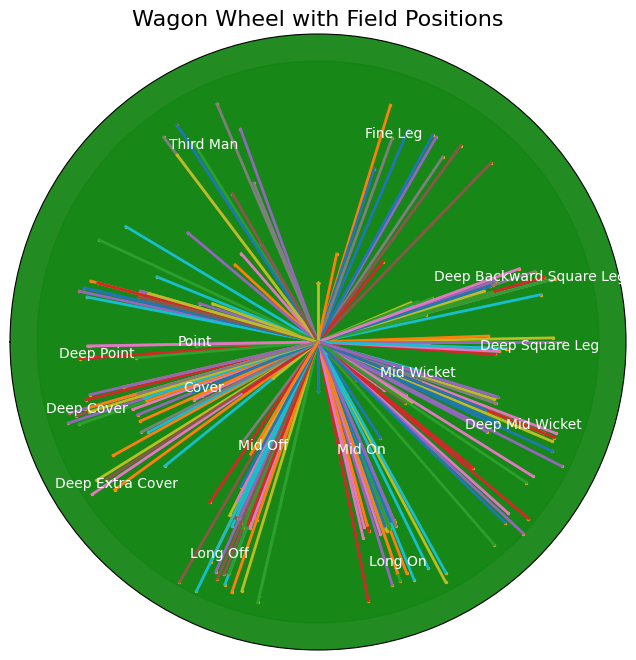

In [35]:
magnitudes = df['Shot Magnitude'].to_list()
angles_deg = df['Shot Angle'].to_list()
angles_rad = np.deg2rad(angles_deg)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'polar': True})

boundary = plt.Circle((0,0), 228, transform=ax.transData._b, color='green', alpha=0.3)
ax.add_artist(boundary)

pitch_width = 10
pitch_length = 22

ax.set_ylim(0, 250)  # max distance

field_positions = {
    # Off Side Positions
    'Long Off': (295, 190),
    'Deep Cover': (344, 195),
    'Deep Extra Cover': (325, 200),
    'Deep Point': (357, 180),  # Merged with Deep Backward Point for simplicity
    'Third Man': (60, 185), # Note: Your data has multiple clusters for Third Man

    # On Side Positions
    'Long On': (250, 190),
    'Deep Mid Wicket': (202, 180),
    'Deep Square Leg': (181, 180),
    'Deep Backward Square Leg': (163, 180),
    'Fine Leg': (110, 180),

    # Inner Circle / Other
    'Mid Off': (298, 95),
    'Mid On': (248, 94),
    'Cover': (338, 100),
    'Mid Wicket': (197, 85),
    'Point': (0, 100),
}

for pos, (angle_deg, radius) in field_positions.items():
    angle_rad = np.deg2rad(angle_deg)
    ax.text(angle_rad, radius, pos, fontsize=10, ha='center', va='center', color='white')


for angle, mag in zip(angles_rad, magnitudes):
    ax.plot([angle, angle], [0, mag], linewidth=2)
    ax.scatter(angle, mag, color='orange', s=2)  # shot endpoint


# Customize plot
ax.set_facecolor('forestgreen')
ax.set_theta_zero_location('W')   # zero at top (north)
ax.set_theta_direction(-1)        # clockwise

ax.grid(False)
ax.set_yticklabels([])
ax.set_xticklabels([])

plt.title('Wagon Wheel with Field Positions', color='Black', fontsize=16)
plt.show()


In [36]:
def wicketball(x):
    if x != 0:
        return 1
    else:
        return 0
df['iswicket']= df['Fall Of Wickets'].apply(wicketball)
df['iswicket'] = df['iswicket'].astype('int')
DT_Analysis = df.groupby(['Bowling Team', 'Delivery Type']).agg(runs=('Runs', 'sum'), balls=('Balls', 'count'), wicket=('iswicket', 'sum'))
DT_Analysis['Striker Rate']=round((DT_Analysis['runs']/DT_Analysis['balls'])*100,2)
DT_Analysis.sort_values('Striker Rate', ascending=False)
DT_Analysis

runs  balls  wicket  Striker Rate
Bowling Team        Delivery Type                                      
Rajasthan Royals    CarromBall           7      4       0        175.00
                    InSwinger            6      3       0        200.00
                    Leg Cutter           8      2       0        400.00
                    Off Break           39     19       0        205.26
                    Off Cutter          59     30       1        196.67
                    Out Swing           13      6       0        216.67
                    QuickerBall         15     12       2        125.00
                    Reverse InSwing      4      1       0        400.00
                    Reverse OutSwing     2      1       0        200.00
                    Seam Away            1      1       0        100.00
                    Slower Ball         16      5       0        320.00
                    Straight Ball      116     49       3        236.73
Sunrisers Hyderabad Arm Ball             4      2       0        200.00
                    Googly              13      4       0        325.00
                    InSwinger            6      3       0        200.00
                    Leg Break           35     21       1        166.67
                    Leg Cutter           5      4       0        125.00
                    Off Cutter          47     30       1        156.67
                    Out Swing           16     12       0        133.33
                    SeamIn               6      2       0        300.00
                    Slower Ball          1      1       0        100.00
                    Stock Ball          13     10       0        130.00
                    Straight Ball       96     40       4        240.00

## Batting Analysis

In [37]:
ST_Analysis = df.groupby(['Shot Type', 'Batting Team']).agg(runs=('Runs', 'sum'), balls=('Balls', 'count'), wicket=('iswicket', 'sum'))
ST_Analysis['Striker Rate']=round((ST_Analysis['runs']/ST_Analysis['balls'])*100,2)

In [38]:
ST_Analysis.sort_values('wicket', ascending=False)
ST_Analysis.to_csv('ST_Analysis.csv')

In [39]:
ST_Analysis.sort_values('runs', ascending=False)

runs  balls  wicket  Striker Rate
Shot Type         Batting Team                                          
Drive             Sunrisers Hyderabad    89     41       2        217.07
                  Rajasthan Royals       58     29       0        200.00
Pull              Rajasthan Royals       58     31       3        187.10
Slog              Rajasthan Royals       52     16       1        325.00
Cut               Sunrisers Hyderabad    47     22       0        213.64
Pull              Sunrisers Hyderabad    47     15       0        313.33
Slog              Sunrisers Hyderabad    32     20       3        160.00
Flick             Sunrisers Hyderabad    22      8       1        275.00
Slog Sweep        Rajasthan Royals       15      5       1        300.00
                  Sunrisers Hyderabad    15      4       0        375.00
Cut               Rajasthan Royals       15     17       1         88.24
UpperCut          Rajasthan Royals       14      5       0        280.00
Flick             Rajasthan Royals       12      3       0        400.00
Worked            Rajasthan Royals        9     10       0         90.00
UpperCut          Sunrisers Hyderabad     7      4       0        175.00
Leave             Rajasthan Royals        5      7       0         71.43
                  Sunrisers Hyderabad     5      5       0        100.00
Forward Defensive Sunrisers Hyderabad     4      1       0        400.00
Steer             Sunrisers Hyderabad     4      1       0        400.00
Pushed            Rajasthan Royals        4      3       0        133.33
Reverse Sweep     Sunrisers Hyderabad     4      1       0        400.00
Worked            Sunrisers Hyderabad     4      4       0        100.00
Sweep             Sunrisers Hyderabad     3      3       0        100.00
Hook              Sunrisers Hyderabad     2      2       0        100.00
Pushed            Sunrisers Hyderabad     1      1       0        100.00
LateCut           Rajasthan Royals        0      1       0          0.00
Forward Defensive Rajasthan Royals        0      1       0          0.00
Dropped           Sunrisers Hyderabad     0      1       0          0.00
Sweep             Rajasthan Royals        0      1       0          0.00